In [1]:
import scanpy as sc

In [2]:
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem/")
import matplotlib.pyplot as plt

In [3]:
ms_A1=sc.read_h5ad('data/sma/V11L12-109_A1/ms.h5ad')
ms_B1=sc.read_h5ad('data/sma/V11L12-109_B1/ms.h5ad')
ms_C1=sc.read_h5ad('data/sma/V11L12-109_C1/ms.h5ad')

st_A1=sc.read_h5ad('data/sma/V11L12-109_A1/st.h5ad')
st_B1=sc.read_h5ad('data/sma/V11L12-109_B1/st.h5ad')
st_C1=sc.read_h5ad('data/sma/V11L12-109_C1/st.h5ad')

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
st_A1.uns["spatial"]["V11L12-109_A1"]["images"]["hires"]

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]], dtype=float32)

In [5]:
def he_coor(adata_omics1,adata_omics2):
    key=list(adata_omics1.uns["spatial"].keys())[0]
    adata_omics1.obsm["HE_domain_coor"]=adata_omics1.obsm["spatial"]*adata_omics1.uns["spatial"][key]["scalefactors"]["tissue_hires_scalef"]
    adata_omics2.obsm["HE_domain_coor"]=adata_omics2.obsm["spatial"]

In [6]:
def re_img(adata):
    key=list(adata.uns["spatial"].keys())[0]
    return adata.uns["spatial"][key]["images"]["hires"]

In [7]:
he_coor(st_A1,ms_A1)
he_coor(st_B1,ms_B1)
he_coor(st_C1,ms_C1)

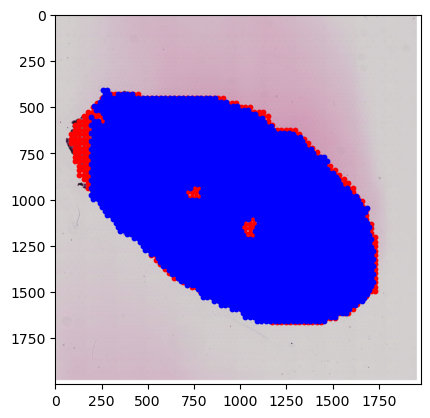

In [8]:
plt.scatter(ms_A1.obsm["HE_domain_coor"][:,0],ms_A1.obsm["HE_domain_coor"][:,1],s=10,c="red")
plt.scatter(st_A1.obsm["HE_domain_coor"][:,0],st_A1.obsm["HE_domain_coor"][:,1],s=10,c="blue")
plt.imshow(re_img(st_A1))
# plt.xlim(500,800)
# plt.ylim(500,800)

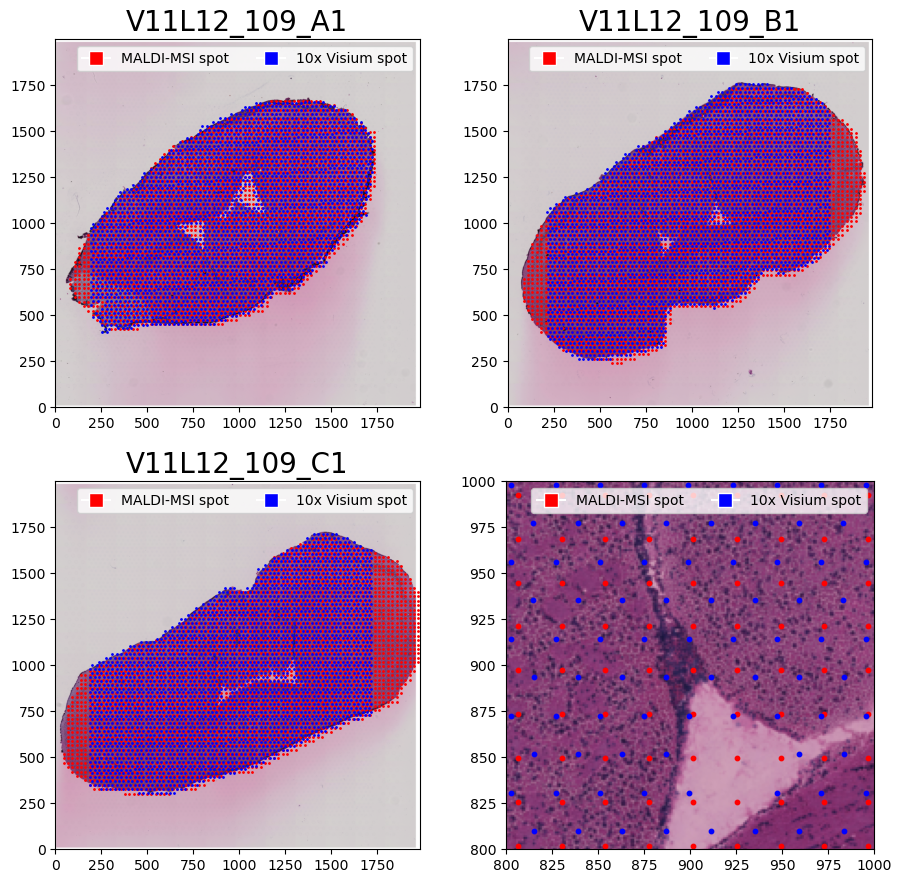

In [9]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='MALDI-MSI spot',       markerfacecolor="red", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='10x Visium spot',       markerfacecolor="blue", markersize=10)
]

fig,axs=plt.subplots(2,2,figsize=(9,9))
s_1=1
axs[0,0].scatter(ms_A1.obsm["HE_domain_coor"][:,0],ms_A1.obsm["HE_domain_coor"][:,1],s=s_1,c="red")
axs[0,0].scatter(st_A1.obsm["HE_domain_coor"][:,0],st_A1.obsm["HE_domain_coor"][:,1],s=s_1,c="blue")
axs[0,0].imshow(re_img(st_A1))

axs[0,1].scatter(ms_B1.obsm["HE_domain_coor"][:,0],ms_B1.obsm["HE_domain_coor"][:,1],s=s_1,c="red")
axs[0,1].scatter(st_B1.obsm["HE_domain_coor"][:,0],st_B1.obsm["HE_domain_coor"][:,1],s=s_1,c="blue")
axs[0,1].imshow(re_img(st_B1))

axs[1,0].scatter(ms_C1.obsm["HE_domain_coor"][:,0],ms_C1.obsm["HE_domain_coor"][:,1],s=s_1,c="red")
axs[1,0].scatter(st_C1.obsm["HE_domain_coor"][:,0],st_C1.obsm["HE_domain_coor"][:,1],s=s_1,c="blue")
axs[1,0].imshow(re_img(st_C1))

axs[1,1].scatter(ms_C1.obsm["HE_domain_coor"][:,0],ms_C1.obsm["HE_domain_coor"][:,1],s=10,c="red")
axs[1,1].scatter(st_C1.obsm["HE_domain_coor"][:,0],st_C1.obsm["HE_domain_coor"][:,1],s=10,c="blue")
axs[1,1].imshow(re_img(st_C1))
axs[1,1].set_xlim(800,1000)
axs[1,1].set_ylim(1000,800)

axs[0,0].legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
axs[0,1].legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
axs[1,0].legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
axs[1,1].legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)
for i in axs:
    for j in i:
        j.invert_yaxis()
axs[0,0].set_title("V11L12_109_A1",fontsize=20)
axs[0,1].set_title("V11L12_109_B1",fontsize=20)
axs[1,0].set_title("V11L12_109_C1",fontsize=20)
plt.subplots_adjust(left=0.02, bottom=0.05, right=0.98, top=0.95, wspace=0.1, hspace=0.2)

fig.savefig("plot/s7.1.png")